In [714]:
import numpy as np

In [715]:
N = 10000
n = 5 #features
m = 2 #targets
D = [16,16] #number of hidden units
D = [n] + D + [2*m]
K = len(D)-2 #number of hidden layers


In [716]:
rng = np.random.default_rng(0)

In [717]:
h = 2*n
W1_true = rng.normal(-0.2,1.0,size=(h,n))
b1_true = rng.normal(-0.2,0.3, size=(h,1))
W2_true = rng.normal(-0.5,1.0,size=(m,h))
b2_true = rng.normal(-0.1,0.3, size=(m,1))

X = rng.uniform(-1.0,1.0,size=(n,N))

In [718]:
def ReLU(X):
    X = np.asarray(X)
    return np.maximum(0,X)

In [719]:
Y_clean = W2_true @ ReLU(W1_true @ X + b1_true) + b2_true # (m,N)
Y_clean.shape

(2, 10000)

In [720]:
noise_std = 0.1*np.std(Y_clean, axis=1,keepdims=True)
eps = rng.normal(0.0, noise_std, size=(m,N))
Y = Y_clean + eps
Y.shape

(2, 10000)

In [721]:
idx = rng.permutation(N)
val_frac = 0.2
n_val = int(val_frac*N)
val_idx = idx[:n_val]
train_idx = idx[n_val:]

In [722]:
X_train, Y_train = X[:,train_idx], Y[:,train_idx]
X_val, Y_val = X[:,val_idx], Y[:,val_idx]

In [723]:
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape

((5, 8000), (2, 8000), (5, 2000), (2, 2000))

In [724]:
def init_params(D=D):
    Weights = []
    bias = []
    for l in range(1,len(D)):
        W = rng.normal(0.0, np.sqrt(2/D[l-1]),size=(D[l],D[l-1]))
        Weights.append(W)
        b = rng.normal(0.0, np.sqrt(2/D[l]),size=(D[l],1))
        bias.append(b)
    return Weights, bias 

In [725]:
def forward(X,W,b):
    H,Z = [X], [] # K+1,K | Z is shifted <- to H
    for l in range(len(W)):
        Z_l = W[l]@H[l]+b[l]
        if(l != len(W)-1):
            H_l = ReLU(Z_l)
        else:
            H_l = Z_l
        H.append(H_l); Z.append(Z_l)
    Thehta = H[-1]
    return Thehta, H,Z

In [726]:
def Loss_NLL(Thehta, Y):
    #Thehta (2m,N)
    m,N = Y.shape
    mu = Thehta[0:m,:] #(m,N)
    s = Thehta[m:,:] ##(m,N)
    s = np.clip(s,-10,5)
    r = mu - Y #(m,n)
    return (1/(2*N)) * np.sum(np.log(2*np.pi) + s + (r**2)*np.exp(-s))

In [727]:
def backprop(Theta,Y,H,Z,W):
    #Y_hat, Y: (m,n)
    #H[0]: (n,N) H[l]: (d_l, N)
    # Z[l]: (d_{l+1}, N)
    # W[l]: (d_{l+1}, d_l)

    m,N = Y.shape
    mu = Theta[0:m, :]
    s  = Theta[m:2*m, :]
    s = np.clip(s,-10,5)
    r = mu-Y
    L = len(W) #number of layers (K)
    ones = np.ones(shape=(N,1))

    dW, db = [None]*L, [None]*L

    G = np.zeros_like(Theta)   
    G[0:m,:] = (mu-Y)*np.exp(-s)/N #(1,N)
    G[m:,:] = (1-(r**2)*np.exp(-s))/(2*N)

    dW[L-1] = G @ H[L-1].T #(m,N)(N,d_K)
    db[L-1] = G @ ones #(m,N)(N,1)

    for l in range(L-2,-1,-1):
        dH = W[l+1].T @ G #(d+{l+1},N)
        
        mask = (Z[l]>0)#(d_{l+1},N)
        G = dH*mask

        dW[l] = G @ H[l].T #(d_{l+1},N)(N,d_l)
        db[l] = G @ ones #(d_{l+1},N)(N,1)
    
    return dW,db

In [728]:
def update_params(W, b, dW, db, lr):
    K = len(W)
    W_new = [W[l] - lr * dW[l] for l in range(K)]
    b_new = [b[l] - lr * db[l] for l in range(K)]
    return W_new, b_new

In [729]:
def train_step(X_batch, Y_batch, W,b, lr):
    Y_hat, H, Z = forward(X_batch,W,b)
    L = Loss_NLL(Y_hat, Y_batch)
    dW,db = backprop(Y_hat,Y_batch,H,Z,W)
    W,b = update_params(W,b,dW,db,lr)
    return L, W, b

In [730]:
def fit(X_train, Y_train, W,b, lr=3e-3, epochs=100, batch_size=128,
        X_val=None, Y_val=None, rng=None, print_every=10):
    if rng is None:
        rng = np.random.default_rng(0)
    
    N = X_train.shape[1]
    history = {"train_loss":[], "val_loss":[]}

    for ep in range(1, epochs+1):
        idx = rng.permutation(N)
        train_losses = []

        for start in range(0,N, batch_size):
            batch_idx = idx[start:start+batch_size]
            
            Xb = X_train[:,batch_idx]
            Yb = Y_train[:,batch_idx]

            Lb,W,b= train_step(Xb,Yb,W,b,lr)
            train_losses.append(Lb)

        train_loss = float(np.mean(train_losses))
        history["train_loss"].append(train_loss)

        if X_val is not None and Y_val is not None:
            Y_hat_val,_,_ = forward(X_val,W,b)
            val_loss = float(Loss_NLL(Y_hat_val,Y_val))
            history["val_loss"].append(val_loss)
            
        if (ep % print_every == 0) or (ep == 1) or (ep == epochs):
            if X_val is not None and Y_val is not None:
                print(f"epoch {ep:4d}/{epochs} | train_loss={train_loss:.6f} | val_loss={history['val_loss'][-1]:.6f}")
            else:
                print(f"epoch {ep:4d}/{epochs} | train_loss={train_loss:.6f}")
    return W,b, history

In [731]:
W, b = init_params(D)
W, b, history = fit(X_train,Y_train,W,b,X_val=X_val,Y_val=Y_val)
history

epoch    1/100 | train_loss=6.665836 | val_loss=4.399845
epoch   10/100 | train_loss=3.192147 | val_loss=3.152257
epoch   20/100 | train_loss=2.495727 | val_loss=2.484565
epoch   30/100 | train_loss=1.931750 | val_loss=1.939801
epoch   40/100 | train_loss=1.470060 | val_loss=1.487391
epoch   50/100 | train_loss=1.111595 | val_loss=1.144072
epoch   60/100 | train_loss=0.893267 | val_loss=0.925345
epoch   70/100 | train_loss=0.738885 | val_loss=0.767700
epoch   80/100 | train_loss=0.602691 | val_loss=0.657174
epoch   90/100 | train_loss=0.471062 | val_loss=0.497196
epoch  100/100 | train_loss=0.373168 | val_loss=0.506623


{'train_loss': [6.665836370357903,
  4.233295322293459,
  4.006174356282227,
  3.8469002742875467,
  3.709089258383756,
  3.586738927766613,
  3.475316603521593,
  3.37394849060499,
  3.2778215559443846,
  3.192146722816639,
  3.1086853896209887,
  3.026631033105051,
  2.9535192103635657,
  2.881873741862447,
  2.8147352055785606,
  2.7492055609627464,
  2.6856489446762986,
  2.6212172362670048,
  2.5590783774153634,
  2.495726858066086,
  2.4342632102922854,
  2.370604233692045,
  2.3120207038914895,
  2.250814740379544,
  2.196223032497687,
  2.13956455292372,
  2.0867200461313895,
  2.0336098429105283,
  1.9823101592593046,
  1.9317495672966791,
  1.8829719472479183,
  1.8334479458350514,
  1.7840279661453617,
  1.7359376647026468,
  1.6888314409387821,
  1.6449676260369614,
  1.5966582061012335,
  1.554648495768942,
  1.51047588601599,
  1.4700603002621928,
  1.427339885773542,
  1.3886493941353795,
  1.3512081696130789,
  1.3110393522788404,
  1.2739694267271529,
  1.2421753756560

In [732]:
def InferenceGaussian(X,W,b, return_sigma2=True,return_interval=True,z=1.96):
    Theta,_,_ = forward(X,W,b)
    mu = Theta[:m,:] #(m,n)
    s = Theta[m:,:]  #(m,n)

    sigma2 = np.exp(s)
    y_hat = mu

    if return_interval:
        sigma = np.sqrt(sigma2)
        lo = mu - z*sigma
        hi = mu + z*sigma
        if return_sigma2:
            return y_hat, sigma2, (lo,hi)
        return y_hat, (lo, hi)
    if return_sigma2:
        return y_hat,sigma2

    return y_hat

In [733]:
y_hat, sigma2, (lo,hi) = InferenceGaussian(X,W,b)
y_hat, sigma2, lo, hi

(array([[-3.81255845,  1.92937613, -0.02741684, ..., -3.86669052,
         -1.16312694,  3.26150551],
        [-0.28617325, -0.46649758,  0.04475454, ...,  2.03590421,
         -3.13047879, -4.98840207]], shape=(2, 10000)),
 array([[0.07658458, 0.13235806, 0.13630555, ..., 0.10876856, 0.14118526,
         0.14591926],
        [0.04323901, 0.07601662, 0.06325609, ..., 0.04121533, 0.05701286,
         0.04210939]], shape=(2, 10000)),
 array([[-4.35496727,  1.21630759, -0.75104063, ..., -4.51310008,
         -1.89958963,  2.51279768],
        [-0.69373551, -1.00689138, -0.44820042, ...,  1.63799365,
         -3.59847518, -5.3906053 ]], shape=(2, 10000)),
 array([[-3.27014963,  2.64244466,  0.69620695, ..., -3.22028096,
         -0.42666424,  4.01021334],
        [ 0.12138901,  0.07389621,  0.5377095 , ...,  2.43381478,
         -2.6624824 , -4.58619884]], shape=(2, 10000)))

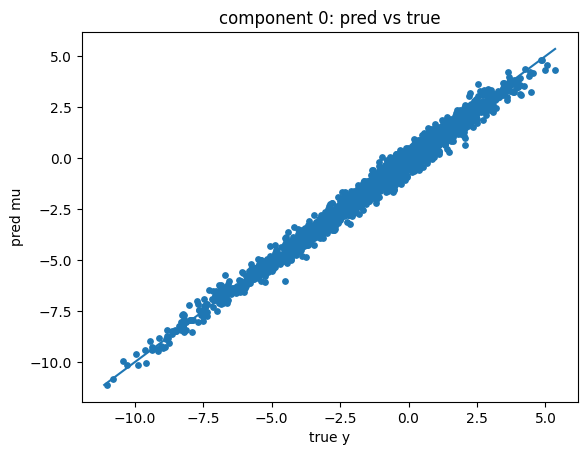

-10.994746145854101 5.558419317263765 -11.111625485051253 5.813572626729143 0.027476142420561196 0.21299453610460253
(2, 2000) (2, 2000)



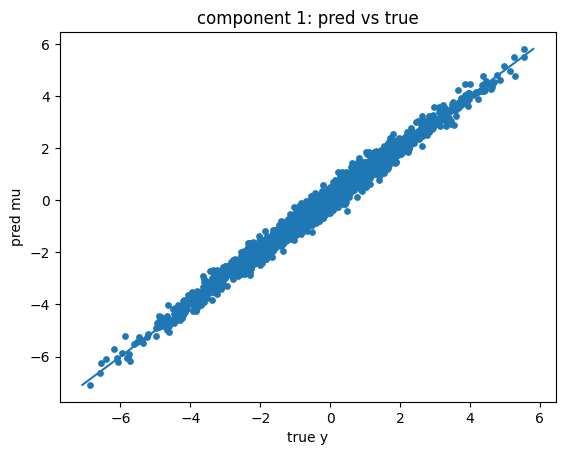

-10.994746145854101 5.558419317263765 -11.111625485051253 5.813572626729143 0.027476142420561196 0.21299453610460253
(2, 2000) (2, 2000)



In [734]:
import matplotlib.pyplot as plt

y_hat, sigma2 = InferenceGaussian(X_val, W, b, return_interval=False, return_sigma2=True)

for d in range(Y_val.shape[0]):
    plt.figure()
    plt.scatter(Y_val[d,:], y_hat[d,:], s=15)
    mn = min(Y_val[d,:].min(), y_hat[d,:].min())
    mx = max(Y_val[d,:].max(), y_hat[d,:].max())
    plt.plot([mn, mx], [mn, mx]) 
    plt.xlabel("true y")
    plt.ylabel("pred mu")
    plt.title(f"component {d}: pred vs true")
    plt.show()
    print(Y_val.min(), Y_val.max(),y_hat.min(), y_hat.max(),sigma2.min(), sigma2.max())
    print(Y_val.shape, y_hat.shape)
    print()

In [735]:
#--------------------------------------------MULTICLASS-------------------------------------------------------------------------------------------------

In [736]:
N = 10000
n = 5 #features
C = 5 #number of classes
m = 5 #targets
out = m*C
D = [64,64,32] #number of hidden units
D = [n] + D + [out]
K = len(D)-2 #number of hidden layers

In [737]:
h = C*n
W1_true = rng.normal(-0.2,1.0,size=(h,n))
b1_true = rng.normal(-0.2,0.3, size=(h,1))
W2_true = rng.normal(-0.5,1.0,size=(m,h))
b2_true = rng.normal(-0.1,0.3, size=(m,1))

X = rng.uniform(-1.0,1.0,size=(n,N))

In [738]:
Y_clean = W2_true @ ReLU(W1_true @ X + b1_true) + b2_true # (m,N)
Y_clean.shape

(5, 10000)

In [739]:
noise_std = 0.1*np.std(Y_clean, axis=1,keepdims=True)
eps = rng.normal(0.0, noise_std, size=(m,N))
Y_cont = Y_clean + eps

qs = np.linspace(0,1,C+1)
Y = np.zeros_like(Y_cont,dtype=np.int64)

for t in range(m):
    edges = np.quantile(Y_cont[t], qs)   # (C+1,) 
    Y[t] = np.digitize(Y_cont[t], edges[1:-1], right=False)

print(Y.min(), Y.max())

Y.shape, Y.dtype, Y.min(), Y.max()

0 4


((5, 10000), dtype('int64'), np.int64(0), np.int64(4))

In [740]:
idx = rng.permutation(N)
val_frac = 0.2
n_val = int(val_frac*N)
val_idx = idx[:n_val]
train_idx = idx[n_val:]

In [741]:
X_train, Y_train = X[:,train_idx], Y[:,train_idx]
X_val, Y_val = X[:,val_idx], Y[:,val_idx]

X_train.shape, Y_train.shape, X_val.shape, Y_val.shape

In [742]:
def init_params(D=D):
    Weights = []
    bias = []
    for l in range(1,len(D)):
        W = rng.normal(0.0, np.sqrt(2/D[l-1]),size=(D[l],D[l-1]))
        Weights.append(W)
        b = rng.normal(0.0, np.sqrt(2/D[l]),size=(D[l],1))
        bias.append(b)
    return Weights, bias 

In [743]:
def forward(X,W,b):
    H,Z = [X], [] # K+1,K | Z is shifted <- to H
    for l in range(len(W)):
        Z_l = W[l]@H[l]+b[l]
        if(l != len(W)-1):
            H_l = ReLU(Z_l)
        else:
            H_l = Z_l
        H.append(H_l); Z.append(Z_l)
    Thehta = H[-1]
    return Thehta, H,Z

In [744]:
def Loss_CEL(Theta, Y):
    #Thehta (C*m,N)
    m,N = Y.shape
    C = Theta.shape[0]//m
    Theta = Theta.reshape(m,C,N)

    Theta = Theta - np.max(Theta,axis=1,keepdims=True) #anti overflow
    logS = np.log(np.sum(np.exp(Theta),axis=1)) #(m,N)

    t_idx = np.arange(m)[:,None] #(m,1)
    n_idx = np.arange(N)[None,:] #(1,N)
    fy = Theta[t_idx, Y, n_idx] #(m,N)

    return -np.sum(fy-logS)/(m*N) #scalar

In [745]:
def softmax(Z):
    Z = Z - np.max(Z,axis=1,keepdims=True) #anti overflow
    expZ = np.exp(Z)
    S = np.sum(expZ,axis=1,keepdims=True)
    return (expZ/S)

In [746]:
def backprop(Theta,Y,H,Z,W):
    #Y_hat, Y: (m,n)
    #H[0]: (n,N) H[l]: (d_l, N)
    # Z[l]: (d_{l+1}, N)
    # W[l]: (d_{l+1}, d_l)

    m,N = Y.shape
    
    L = len(W) #number of layers (K)
    ones = np.ones(shape=(N,1))

    dW, db = [None]*L, [None]*L

    m,N = Y.shape
    C = Theta.shape[0]//m

    onehot = np.zeros(shape=(m,C,N))
    t_idx = np.arange(m)[:,None] #(m,1)
    n_idx = np.arange(N)[None,:] #(1,N)
    onehot[t_idx,Y,n_idx] = 1.0
    G = (softmax(Theta.reshape(m,C,N)) - onehot).reshape(m*C,N)
    G /= (m*N)

    dW[L-1] = G @ H[L-1].T #(m,N)(N,d_K)
    db[L-1] = G @ ones #(m,N)(N,1)

    for l in range(L-2,-1,-1):
        dH = W[l+1].T @ G #(d+{l+1},N)
        
        mask = (Z[l]>0)#(d_{l+1},N)
        G = dH*mask

        dW[l] = G @ H[l].T #(d_{l+1},N)(N,d_l)
        db[l] = G @ ones #(d_{l+1},N)(N,1)
    
    return dW,db

In [747]:
def update_params(W, b, dW, db, lr):
    K = len(W)
    W_new = [W[l] - lr * dW[l] for l in range(K)]
    b_new = [b[l] - lr * db[l] for l in range(K)]
    return W_new, b_new

In [748]:
def train_step(X_batch, Y_batch, W,b, lr):
    Y_hat, H, Z = forward(X_batch,W,b)
    L = Loss_CEL(Y_hat, Y_batch)
    dW,db = backprop(Y_hat,Y_batch,H,Z,W)
    W,b = update_params(W,b,dW,db,lr)
    return L, W, b

In [749]:
def fit(X_train, Y_train, W,b, lr=5e-2, epochs=300, batch_size=64,
        X_val=None, Y_val=None, rng=None, print_every=10):
    if rng is None:
        rng = np.random.default_rng(0)
    
    N = X_train.shape[1]
    history = {"train_loss":[], "val_loss":[]}

    for ep in range(1, epochs+1):
        idx = rng.permutation(N)
        train_losses = []

        for start in range(0,N, batch_size):
            batch_idx = idx[start:start+batch_size]
            
            Xb = X_train[:,batch_idx]
            Yb = Y_train[:,batch_idx]

            Lb,W,b= train_step(Xb,Yb,W,b,lr)
            train_losses.append(Lb)

        train_loss = float(np.mean(train_losses))
        history["train_loss"].append(train_loss)

        if X_val is not None and Y_val is not None:
            Y_hat_val,_,_ = forward(X_val,W,b)
            val_loss = float(Loss_CEL(Y_hat_val,Y_val))
            history["val_loss"].append(val_loss)
            
        if (ep % print_every == 0) or (ep == 1) or (ep == epochs):
            if X_val is not None and Y_val is not None:
                print(f"epoch {ep:4d}/{epochs} | train_loss={train_loss:.6f} | val_loss={history['val_loss'][-1]:.6f}")
            else:
                print(f"epoch {ep:4d}/{epochs} | train_loss={train_loss:.6f}")
        
    return W,b, history

In [750]:
W, b = init_params(D)
W_new, b_new, history = fit(X_train,Y_train,W,b,X_val=X_val,Y_val=Y_val)
history

epoch    1/300 | train_loss=1.540391 | val_loss=1.415152
epoch   10/300 | train_loss=0.748564 | val_loss=0.736485
epoch   20/300 | train_loss=0.547033 | val_loss=0.550748
epoch   30/300 | train_loss=0.463236 | val_loss=0.480881
epoch   40/300 | train_loss=0.419824 | val_loss=0.456194
epoch   50/300 | train_loss=0.388713 | val_loss=0.417149
epoch   60/300 | train_loss=0.367382 | val_loss=0.388788
epoch   70/300 | train_loss=0.354833 | val_loss=0.371913
epoch   80/300 | train_loss=0.337496 | val_loss=0.369588
epoch   90/300 | train_loss=0.327132 | val_loss=0.362946
epoch  100/300 | train_loss=0.320443 | val_loss=0.347539
epoch  110/300 | train_loss=0.317441 | val_loss=0.342974
epoch  120/300 | train_loss=0.308850 | val_loss=0.355772
epoch  130/300 | train_loss=0.300938 | val_loss=0.329967
epoch  140/300 | train_loss=0.297602 | val_loss=0.326805
epoch  150/300 | train_loss=0.293073 | val_loss=0.344193
epoch  160/300 | train_loss=0.291391 | val_loss=0.317339
epoch  170/300 | train_loss=0.2

{'train_loss': [1.5403911876254797,
  1.3325329049239407,
  1.1955020026385912,
  1.085687211169775,
  0.9971236188124731,
  0.9261873455282016,
  0.8685182090163485,
  0.822027589315703,
  0.7830684707562917,
  0.7485636406943114,
  0.7179094429233155,
  0.6904782073509337,
  0.6653735461256323,
  0.6430234602471091,
  0.6221318228696769,
  0.6035437888413027,
  0.5863534552223776,
  0.5715082914677395,
  0.5574767319900834,
  0.5470328306989588,
  0.5347212976465646,
  0.5230524291602212,
  0.5135257911990456,
  0.5056151072344035,
  0.4970097197351967,
  0.4888924362729744,
  0.4819501974698889,
  0.4752742059807491,
  0.4691876747386706,
  0.46323592680127745,
  0.4574443868757104,
  0.4520759756271396,
  0.44663845157691323,
  0.44210586009360303,
  0.4378096485017907,
  0.4336186147223132,
  0.43021957006673417,
  0.4247418684733472,
  0.4204480774344659,
  0.4198236191793724,
  0.41377525718883695,
  0.41334190360072687,
  0.40843691474253996,
  0.40433287778929883,
  0.40144474

In [751]:
def inference(X,W,b,m):
    Theta_flat,_,_ = forward(X,W,b)
    _,N = X.shape
    C = Theta_flat.shape[0]//m
    Theta = Theta_flat.reshape(m,C,N)
    return np.argmax(Theta,axis=1)

In [752]:
Y_hat = inference(X,W_new,b_new,m)
Y_hat

array([[4, 2, 3, ..., 2, 3, 0],
       [2, 4, 2, ..., 3, 3, 0],
       [3, 4, 1, ..., 4, 4, 3],
       [3, 1, 3, ..., 2, 3, 0],
       [3, 2, 2, ..., 1, 2, 0]], shape=(5, 10000))

In [753]:
import matplotlib.pyplot as plt

In [754]:
def Accuracy(X, W, b, Y):
    m, N = Y.shape

    Theta_flat, _, _ = forward(X, W, b)   # (m*C, N)
    C = Theta_flat.shape[0] // m
    Theta = Theta_flat.reshape(m, C, N)

    Y_hat = np.argmax(Theta, axis=1)      # (m, N)
    return np.mean(Y_hat == Y)


In [755]:
Accuracy(X_train, W_new, b_new, Y_train)
Accuracy(X_val,   W_new, b_new, Y_val)


np.float64(0.868)